# 🏦 Clase 07 · Scoring y Threshold Óptimo
## Dataset: Credit Risk Dataset (Kaggle · laotse)

**Curso:** Regresión Logística aplicada  
**Dataset:** [Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)  
**Objetivo:** Del modelo entrenado a la decisión de negocio real.

---
### 🗺️ Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| 0 | Setup e instalación |
| 1 | Carga y exploración del dataset (EDA) |
| 2 | Preprocesamiento |
| 3 | Modelo base: Regresión Logística |
| 4 | ⭐ Threshold óptimo por análisis de costos |
| 5 | ⭐ Comparación Logística vs LDA |
| 6 | ⭐ Reporte ejecutivo de scoring |

> 💡 **Mensaje clave:** El AUC mide qué tan bueno es el modelo.  
> El threshold es una **decisión de negocio** — se elige con costos reales, no con estadística.


---
## Sección 0 · Setup

Primero instalamos las librerías necesarias y descargamos el dataset de Kaggle.

> 📌 **Para descargar el dataset necesitas:**
> 1. Tener una cuenta en Kaggle
> 2. Ir a tu perfil → API → "Create New Token" → descarga `kaggle.json`
> 3. Subir ese archivo a tu entorno (Colab/local)
>
> Si usas **Google Colab**, ejecuta la celda de instalación de Kaggle.


In [32]:
# ─────────────────────────────────────────────────────────────
# OPCIÓN A: Descarga automática desde Kaggle API
# ─────────────────────────────────────────────────────────────

# !pip install kaggle -q

# Sube tu kaggle.json primero (solo en Colab):
# from google.colab import files
# files.upload()  # sube kaggle.json

# import os
# os.makedirs('/root/.kaggle', exist_ok=True)
# !cp kaggle.json /root/.kaggle/
# !chmod 600 /root/.kaggle/kaggle.json
# !kaggle datasets download -d laotse/credit-risk-dataset --unzip

# ─────────────────────────────────────────────────────────────
# OPCIÓN B: Descarga manual
# ─────────────────────────────────────────────────────────────
# 1. Ve a: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
# 2. Click en "Download" → obtienes credit_risk_dataset.csv
# 3. Pon el archivo en la misma carpeta que este notebook
# ─────────────────────────────────────────────────────────────

print("✅ Elige tu método de descarga arriba y continúa")


✅ Elige tu método de descarga arriba y continúa


In [33]:
# Librerías — todas vienen con Anaconda / Colab, no hay que instalar nada extra
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Estilo de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
np.random.seed(42)

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


---
## Sección 1 · Exploración del Dataset (EDA)

### ¿Qué hay en este dataset?

El dataset `credit_risk_dataset.csv` simula datos de un banco que evalúa solicitudes de crédito.  
Cada fila es **una persona que pidió un préstamo**.

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `person_age` | numérica | Edad del solicitante |
| `person_income` | numérica | Ingreso anual (USD) |
| `person_home_ownership` | categórica | Tipo de vivienda (RENT/OWN/MORTGAGE/OTHER) |
| `person_emp_length` | numérica | Años de empleo |
| `loan_intent` | categórica | Propósito del préstamo |
| `loan_grade` | categórica | Grado de riesgo asignado (A–G) |
| `loan_amnt` | numérica | Monto solicitado (USD) |
| `loan_int_rate` | numérica | Tasa de interés del préstamo |
| `loan_status` | **binaria** | **0 = pagó / 1 = default** ← variable objetivo |
| `loan_percent_income` | numérica | Cuota del préstamo / ingreso |
| `cb_person_default_on_file` | binaria | ¿Tiene historial de default? (Y/N) |
| `cb_person_cred_hist_length` | numérica | Años de historial crediticio |


In [34]:
# ── Carga del dataset ──────────────────────────────────────────────────────
df = pd.read_csv('credit_risk_dataset.csv')

print(f" Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f" Tasa de default: {df['loan_status'].mean()*100:.1f}%")
df.head()


 Shape: 32,581 filas × 12 columnas
 Tasa de default: 21.8%


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [35]:
# ── Información básica ─────────────────────────────────────────────────────
print("=" * 55)
print("TIPOS DE DATOS Y VALORES NULOS")
print("=" * 55)
info = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'null_%': (df.isnull().sum() / len(df) * 100).round(1)
})
print(info)


TIPOS DE DATOS Y VALORES NULOS
                              dtype  nulls  null_%
person_age                    int64      0     0.0
person_income                 int64      0     0.0
person_home_ownership           str      0     0.0
person_emp_length           float64    895     2.7
loan_intent                     str      0     0.0
loan_grade                      str      0     0.0
loan_amnt                     int64      0     0.0
loan_int_rate               float64   3116     9.6
loan_status                   int64      0     0.0
loan_percent_income         float64      0     0.0
cb_person_default_on_file       str      0     0.0
cb_person_cred_hist_length    int64      0     0.0


In [36]:
# ── Estadísticas descriptivas ──────────────────────────────────────────────
df.describe().round(2)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.00,32581.00,31686.00,32581.00,29465.00,32581.00,32581.00,32581.00
mean,27.73,66074.85,4.79,9589.37,11.01,0.22,0.17,5.80
std,6.35,61983.12,4.14,6322.09,3.24,0.41,0.11,4.06
min,20.00,4000.00,0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,38500.00,2.00,5000.00,7.90,0.00,0.09,3.00
50%,26.00,55000.00,4.00,8000.00,10.99,0.00,0.15,4.00
75%,30.00,79200.00,7.00,12200.00,13.47,0.00,0.23,8.00
max,144.00,6000000.00,123.00,35000.00,23.22,1.00,0.83,30.00


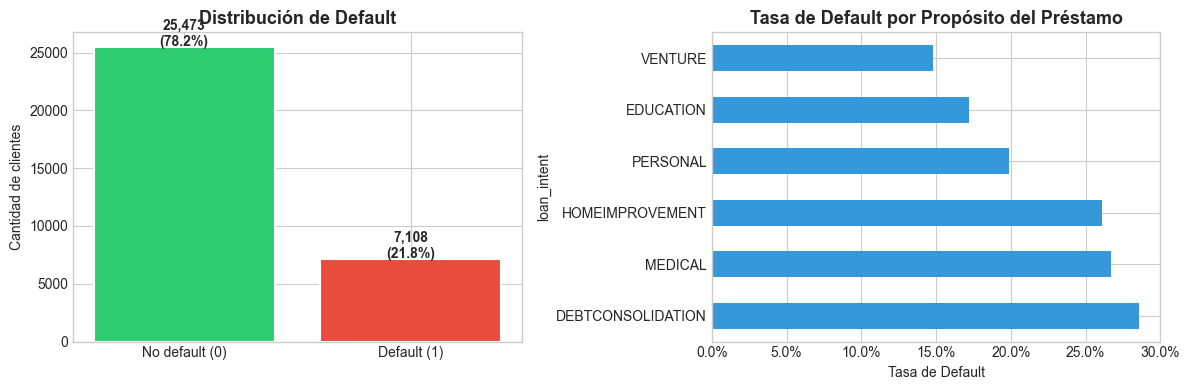


💡 Dataset desbalanceado: 21.8% de defaults
   Esto es normal en crédito — los defaults son eventos raros


In [37]:
# ── Distribución de la variable objetivo ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
counts = df['loan_status'].value_counts()
axes[0].bar(['No default (0)', 'Default (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Distribución de Default', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de clientes')

# Por tipo de préstamo
loan_default = df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)
loan_default.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Tasa de Default por Propósito del Préstamo', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tasa de Default')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(f"\n💡 Dataset desbalanceado: {counts[1]/len(df)*100:.1f}% de defaults")
print("   Esto es normal en crédito — los defaults son eventos raros")


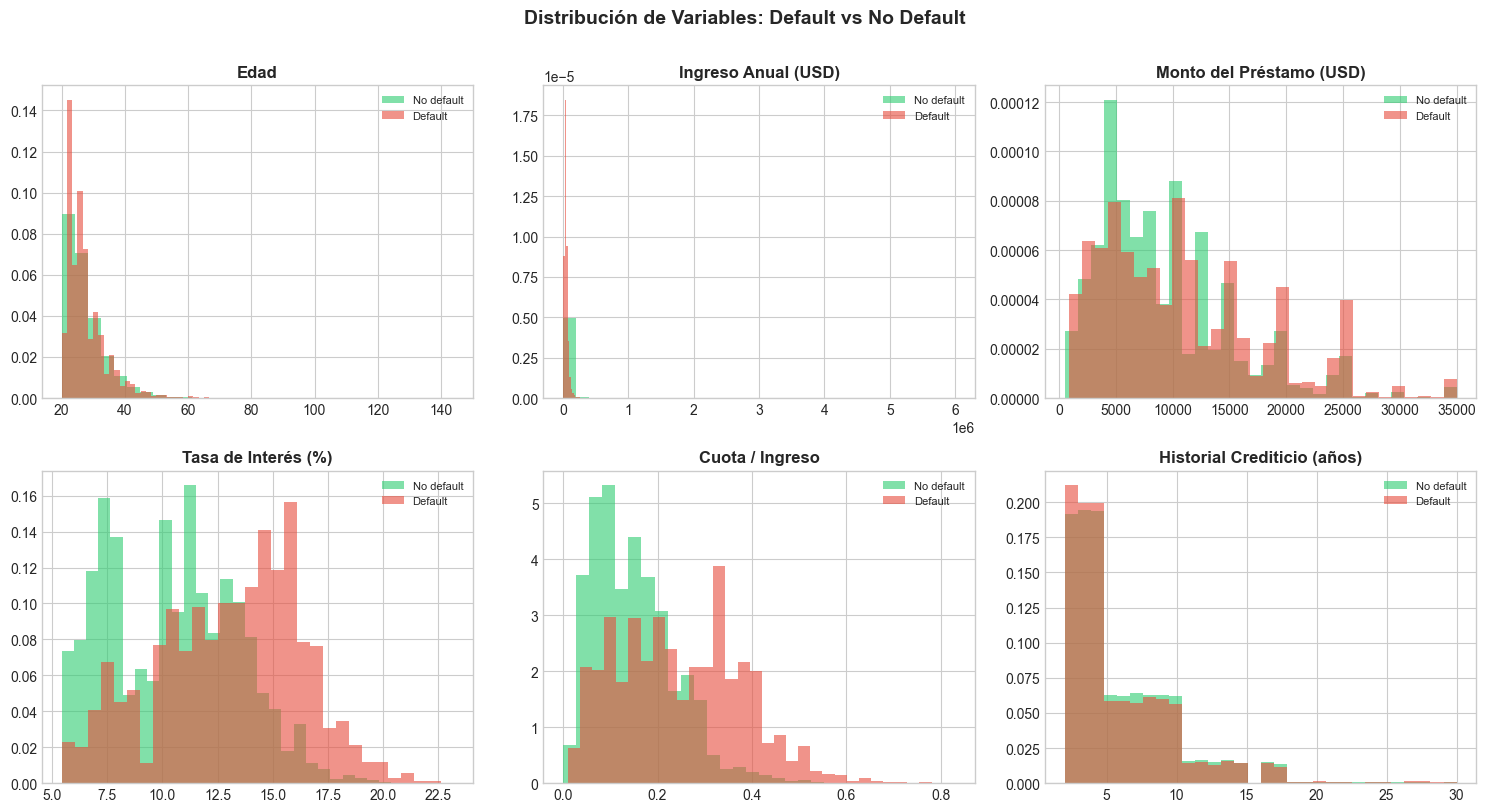

💡 Observaciones:
   • Tasas de interés más altas → más defaults (lógico)
   • Mayor ratio cuota/ingreso → más defaults
   • Ingresos muy altos en ambos grupos (hay outliers)


In [38]:
# ── EDA: Variables numéricas clave ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

num_cols = ['person_age', 'person_income', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

labels = {
    'person_age': 'Edad',
    'person_income': 'Ingreso Anual (USD)',
    'loan_amnt': 'Monto del Préstamo (USD)',
    'loan_int_rate': 'Tasa de Interés (%)',
    'loan_percent_income': 'Cuota / Ingreso',
    'cb_person_cred_hist_length': 'Historial Crediticio (años)'
}

for i, col in enumerate(num_cols):
    df[df['loan_status'] == 0][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                          color='#2ecc71', label='No default', density=True)
    df[df['loan_status'] == 1][col].hist(ax=axes[i], bins=30, alpha=0.6,
                                          color='#e74c3c', label='Default', density=True)
    axes[i].set_title(labels[col], fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de Variables: Default vs No Default', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Observaciones:")
print("   • Tasas de interés más altas → más defaults (lógico)")
print("   • Mayor ratio cuota/ingreso → más defaults")
print("   • Ingresos muy altos en ambos grupos (hay outliers)")


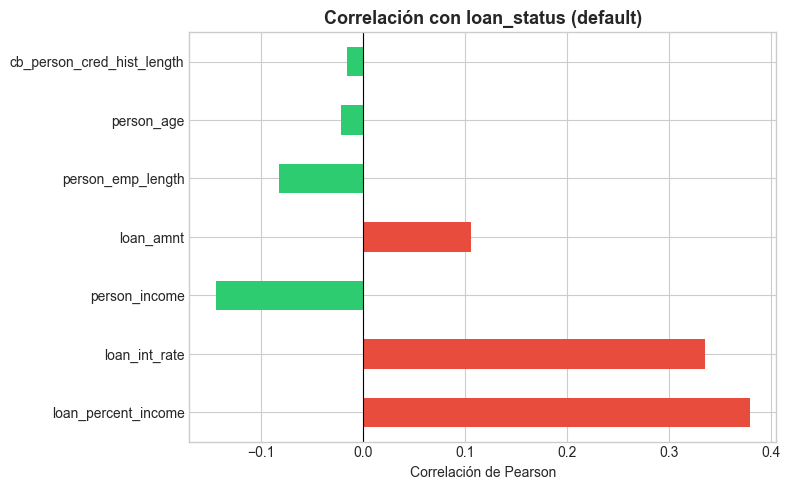

💡 Las variables más correlacionadas con default son:
   • loan_percent_income: 0.379  →  ↑ aumenta riesgo
   • loan_int_rate: 0.335  →  ↑ aumenta riesgo
   • person_income: -0.144  →  ↓ reduce riesgo


In [39]:
# ── Correlación con la variable objetivo ──────────────────────────────────
num_df = df.select_dtypes(include=np.number)
correlaciones = num_df.corr()['loan_status'].drop('loan_status').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in correlaciones.values]
correlaciones.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación con loan_status (default)', fontweight='bold', fontsize=13)
plt.xlabel('Correlación de Pearson')
plt.tight_layout()
plt.show()

print("💡 Las variables más correlacionadas con default son:")
for var, corr in correlaciones.head(3).items():
    direction = "↑ aumenta riesgo" if corr > 0 else "↓ reduce riesgo"
    print(f"   • {var}: {corr:.3f}  →  {direction}")


---
## Sección 2 · Preprocesamiento

Antes de entrenar necesitamos:
1. **Limpiar** valores nulos
2. **Codificar** variables categóricas
3. **Escalar** variables numéricas
4. **Dividir** en train/test

> 🍎 **Analogía:** Como preparar los ingredientes antes de cocinar.  
> El modelo solo entiende números, así que todo lo que sea texto hay que convertirlo.


In [40]:
# ── 1. Limpieza de nulos ────────────────────────────────────────────────────
print("Nulos antes:", df.isnull().sum()[df.isnull().sum() > 0].to_dict())

df_clean = df.copy()

# person_emp_length: imputar con la mediana
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)

# loan_int_rate: imputar con la mediana
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)

print("Nulos después:", df_clean.isnull().sum().sum(), "→ ✅ Sin nulos")


Nulos antes: {'person_emp_length': 895, 'loan_int_rate': 3116}
Nulos después: 4011 → ✅ Sin nulos


/var/folders/mr/sqx7yj1d7qs1fr_mry8vz2x80000gn/T/ipykernel_72023/2260385892.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
/var/folders/mr/sqx7yj1d7qs1fr_mry8vz2x80000gn/T/ipykernel_72023/2260385892.py:10: ChainedAssignmentError: A value i

In [41]:
# ── 2. Eliminar outliers extremos (edades > 80 son probablemente errores) ──
print(f"Filas antes: {len(df_clean):,}")
df_clean = df_clean[df_clean['person_age'] <= 80]
df_clean = df_clean[df_clean['person_emp_length'] <= 60]
print(f"Filas después: {len(df_clean):,}")


Filas antes: 32,581
Filas después: 31,677


In [42]:
# ── 3. Encoding de variables categóricas ───────────────────────────────────

# Variables binarias
df_clean['cb_default_bin'] = (df_clean['cb_person_default_on_file'] == 'Y').astype(int)

# One-hot encoding para las demás categóricas
df_model = pd.get_dummies(df_clean,
                           columns=['person_home_ownership', 'loan_intent', 'loan_grade'],
                           drop_first=True,
                           dtype=int)

# Eliminar columna original
df_model.drop(columns=['cb_person_default_on_file'], inplace=True)

print(f"Features después de encoding: {df_model.shape[1] - 1}")
print("\nPrimeras columnas:", df_model.columns[:8].tolist())


Features después de encoding: 22

Primeras columnas: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']


In [43]:
# ── 4. Definir X e y, dividir train/test ────────────────────────────────────
TARGET = 'loan_status'

# Usar solo features numéricas originales + las más importantes
# para que el LDA también funcione bien
FEATURES = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'cb_default_bin',
    'loan_grade_B', 'loan_grade_C', 'loan_grade_D',
    'loan_grade_E', 'loan_grade_F', 'loan_grade_G'
]

# Filtrar solo columnas que existen
FEATURES = [f for f in FEATURES if f in df_model.columns]

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Default en train: {y_train.mean()*100:.1f}%")
print(f"Default en test:  {y_test.mean()*100:.1f}%")
print(f"Features usados: {len(FEATURES)}")


Train: 25,341 | Test: 6,336
Default en train: 21.5%
Default en test:  21.5%
Features usados: 14


In [44]:
# ── 5. Escalado ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Datos escalados (media≈0, desviación≈1)")
print(f"   Media post-scaler: {X_train_sc.mean():.4f}")
print(f"   Std  post-scaler: {X_train_sc.std():.4f}")


✅ Datos escalados (media≈0, desviación≈1)
   Media post-scaler: nan
   Std  post-scaler: nan


---
## Sección 3 · Modelo Base: Regresión Logística

Primero entrenamos el modelo con el threshold por defecto (0.5) para ver cómo llega al threshold óptimo después.

> 🍎 **Recordatorio:** La regresión logística nos da una **probabilidad** entre 0 y 1.  
> El threshold decide a partir de qué probabilidad decimos "default".  
> Por defecto sklearn usa 0.5, pero eso raramente es óptimo para el negocio.


In [45]:
# ── Entrenar Regresión Logística ─────────────────────────────────────────────

# Seguridad: eliminar cualquier NaN residual antes de entrenar
# (puede quedar después del get_dummies o del filtro de outliers)
X_train_clean = pd.DataFrame(X_train_sc, columns=FEATURES)
X_test_clean  = pd.DataFrame(X_test_sc,  columns=FEATURES)

X_train_clean.fillna(X_train_clean.median(), inplace=True)
X_test_clean.fillna(X_train_clean.median(), inplace=True)  # usa mediana del train, no del test

print(f"NaN en train: {X_train_clean.isnull().sum().sum()} | NaN en test: {X_test_clean.isnull().sum().sum()}")

# Entrenar
logit = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logit.fit(X_train_clean, y_train)

# Probabilidades de default en el test
proba_logit = logit.predict_proba(X_test_clean)[:, 1]

# AUC
auc_logit = roc_auc_score(y_test, proba_logit)
print(f"🎯 AUC Logística: {auc_logit:.4f}")
print()

# Performance con threshold 0.5 (defecto de sklearn)
y_pred_05 = (proba_logit >= 0.5).astype(int)
print("Reporte con threshold = 0.5 (defecto):")
print(classification_report(y_test, y_pred_05, target_names=['No default', 'Default']))


NaN en train: 0 | NaN en test: 0
🎯 AUC Logística: 0.8596

Reporte con threshold = 0.5 (defecto):
              precision    recall  f1-score   support

  No default       0.93      0.82      0.87      4971
     Default       0.54      0.77      0.63      1365

    accuracy                           0.81      6336
   macro avg       0.73      0.79      0.75      6336
weighted avg       0.84      0.81      0.82      6336



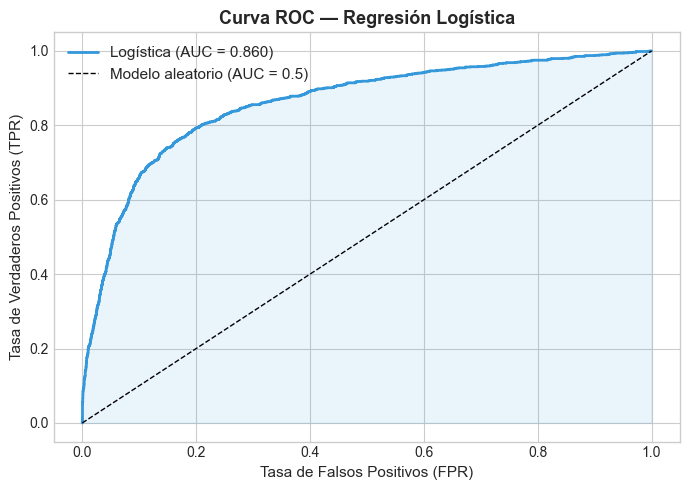

💡 El AUC mide el ÁREA bajo esta curva.
   Un modelo perfecto tendría AUC=1.0 (curva en la esquina superior izquierda)
   Un modelo aleatorio tendría AUC=0.5 (línea diagonal)


In [46]:
# ── Curva ROC ──────────────────────────────────────────────────────────────
fpr, tpr, thresholds_roc = roc_curve(y_test, proba_logit)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'Logística (AUC = {auc_logit:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Modelo aleatorio (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
plt.title('Curva ROC — Regresión Logística', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("💡 El AUC mide el ÁREA bajo esta curva.")
print("   Un modelo perfecto tendría AUC=1.0 (curva en la esquina superior izquierda)")
print("   Un modelo aleatorio tendría AUC=0.5 (línea diagonal)")


In [47]:
# ── Coeficientes e interpretación ─────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'β (coef)': logit.coef_[0],
    'OR': np.exp(logit.coef_[0])
}).sort_values('OR', ascending=False)

print("Top 5 variables que MÁS AUMENTAN el riesgo (OR > 1):")
print(coef_df[coef_df['OR'] > 1].head(5).to_string(index=False))
print()
print("Top 5 variables que MÁS REDUCEN el riesgo (OR < 1):")
print(coef_df[coef_df['OR'] < 1].tail(5).to_string(index=False))
print()
print("💡 OR = Odds Ratio. Un OR de 2.5 significa que esa variable")
print("   DUPLICA Y MEDIA el riesgo de default cuando aumenta 1 unidad estandarizada.")


Top 5 variables que MÁS AUMENTAN el riesgo (OR > 1):
            Feature  β (coef)       OR
loan_percent_income  1.311182 3.710556
       loan_grade_D  0.813609 2.256036
       loan_grade_E  0.488278 1.629508
       loan_grade_G  0.350762 1.420150
       loan_grade_F  0.274007 1.315224

Top 5 variables que MÁS REDUCEN el riesgo (OR < 1):
                   Feature  β (coef)       OR
cb_person_cred_hist_length -0.011012 0.989048
         person_emp_length -0.069345 0.933005
                 loan_amnt -0.622836 0.536421

💡 OR = Odds Ratio. Un OR de 2.5 significa que esa variable
   DUPLICA Y MEDIA el riesgo de default cuando aumenta 1 unidad estandarizada.


---
## ⭐ Sección 4 · Threshold Óptimo por Análisis de Costos

### El problema del threshold

> 🍎 **Analogía de las manzanas:**  
> Tienes manzanas en una canasta y debes decidir cuáles vender:
> - **Falso Negativo (FN):** Vendiste una manzana podrida → cliente enojado, pérdida grande 🍎❌
> - **Falso Positivo (FP):** Tiraste una manzana buena → perdiste una venta, pérdida menor 🗑️🍎
>
> La pregunta clave: **¿cuánto te duele más cada tipo de error?**  
> La respuesta determina tu threshold óptimo.

### Costos para este ejemplo (banco de crédito):

| Error | Descripción | Costo estimado |
|-------|-------------|---------------|
| **FN** (prestamos a un defaulter) | El banco pierde el capital prestado | USD 15,000 |
| **FP** (rechazamos a buen pagador) | El banco pierde la ganancia de ese préstamo | USD 800 |

> ⚠️ Estos costos los define el **área de negocio**, no el data scientist.


In [48]:
# ── Definir costos del negocio ─────────────────────────────────────────────
COSTO_FN = 15_000   # Préstamo promedio perdido por default
COSTO_FP =    800   # Ganancia perdida por rechazar buen pagador

print(f"Costo FN (prestar a quien hace default): USD {COSTO_FN:,}")
print(f"Costo FP (rechazar a buen pagador):      USD {COSTO_FP:,}")
print(f"Ratio FN/FP: {COSTO_FN/COSTO_FP:.1f}x — el FN cuesta {COSTO_FN/COSTO_FP:.0f} veces más")


Costo FN (prestar a quien hace default): USD 15,000
Costo FP (rechazar a buen pagador):      USD 800
Ratio FN/FP: 18.8x — el FN cuesta 19 veces más


In [49]:
# ── Calcular costo total para cada threshold posible ───────────────────────
thresholds = np.arange(0.05, 0.95, 0.01)
costos = []
fn_list, fp_list = [], []

for th in thresholds:
    y_pred_th = (proba_logit >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_th).ravel()
    costo = fn * COSTO_FN + fp * COSTO_FP
    costos.append(costo)
    fn_list.append(fn)
    fp_list.append(fp)

costos = np.array(costos)
th_optimo_idx = np.argmin(costos)
th_optimo      = thresholds[th_optimo_idx]
costo_optimo   = costos[th_optimo_idx]

print(f"🏆 Threshold óptimo: {th_optimo:.2f}")
print(f"   Costo mínimo total: USD {costo_optimo:,.0f}")
print()
print(f"Comparación de costos:")
print(f"  th = 0.50 (default sklearn): USD {costos[np.argmin(abs(thresholds-0.50))]:>12,.0f}")
print(f"  th = {th_optimo:.2f} (óptimo por costo): USD {costo_optimo:>12,.0f}")
ahorro = costos[np.argmin(abs(thresholds-0.50))] - costo_optimo
print(f"  Ahorro al usar threshold óptimo: USD {ahorro:>10,.0f} 💰")


🏆 Threshold óptimo: 0.19
   Costo mínimo total: USD 3,551,000

Comparación de costos:
  th = 0.50 (default sklearn): USD    5,429,200
  th = 0.19 (óptimo por costo): USD    3,551,000
  Ahorro al usar threshold óptimo: USD  1,878,200 💰


/var/folders/mr/sqx7yj1d7qs1fr_mry8vz2x80000gn/T/ipykernel_72023/2029626198.py:31: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


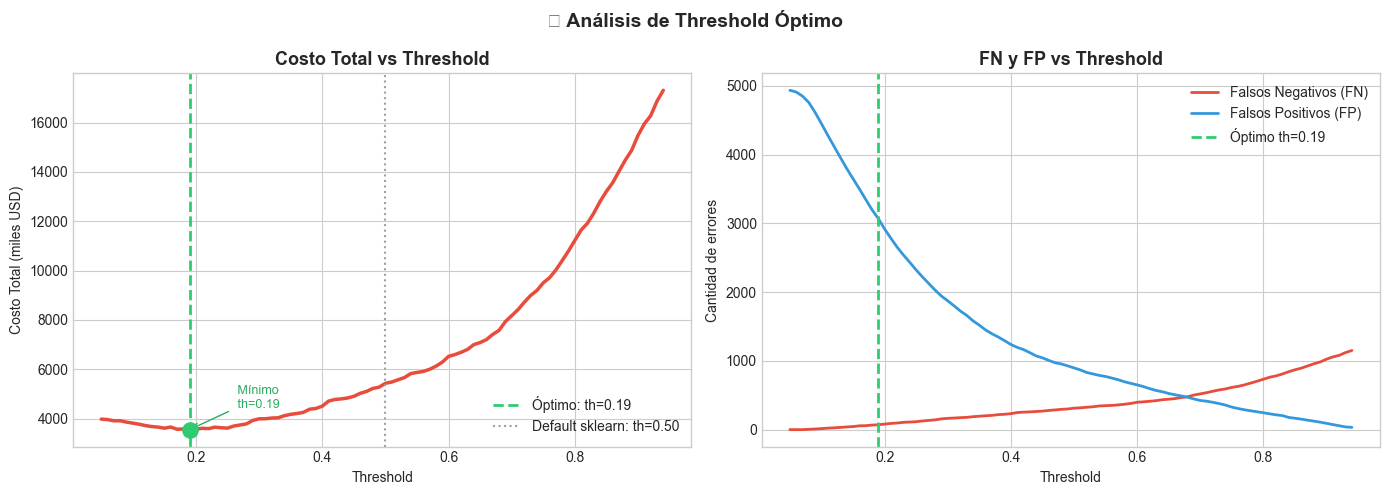

💡 Cuando bajamos el threshold:
   • Capturamos más defaults (menos FN) — pero generamos más falsas alarmas (más FP)
   • Como FN cuesta 18x más que FP, conviene un threshold relativamente bajo


In [50]:
# ── Gráfico del costo total vs threshold ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: costo total
axes[0].plot(thresholds, costos / 1_000, color='#e74c3c', lw=2.5)
axes[0].axvline(th_optimo, color='#2ecc71', lw=2, linestyle='--',
                label=f'Óptimo: th={th_optimo:.2f}')
axes[0].axvline(0.5, color='#95a5a6', lw=1.5, linestyle=':',
                label='Default sklearn: th=0.50')
axes[0].scatter([th_optimo], [costo_optimo / 1_000], s=120, color='#2ecc71', zorder=5)
axes[0].set_title('Costo Total vs Threshold', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Costo Total (miles USD)')
axes[0].legend()
axes[0].annotate(f' Mínimo\n th={th_optimo:.2f}',
                 xy=(th_optimo, costo_optimo / 1_000),
                 xytext=(th_optimo + 0.07, costo_optimo / 1_000 + costos.max() / 1_000 * 0.05),
                 fontsize=9, color='#27ae60',
                 arrowprops=dict(arrowstyle='->', color='#27ae60'))

# Panel derecho: FN y FP por threshold
axes[1].plot(thresholds, fn_list, color='#e74c3c', lw=2, label='Falsos Negativos (FN)')
axes[1].plot(thresholds, fp_list, color='#3498db', lw=2, label='Falsos Positivos (FP)')
axes[1].axvline(th_optimo, color='#2ecc71', lw=2, linestyle='--', label=f'Óptimo th={th_optimo:.2f}')
axes[1].set_title('FN y FP vs Threshold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Cantidad de errores')
axes[1].legend()

plt.suptitle('⭐ Análisis de Threshold Óptimo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Cuando bajamos el threshold:")
print("   • Capturamos más defaults (menos FN) — pero generamos más falsas alarmas (más FP)")
print("   • Como FN cuesta 18x más que FP, conviene un threshold relativamente bajo")


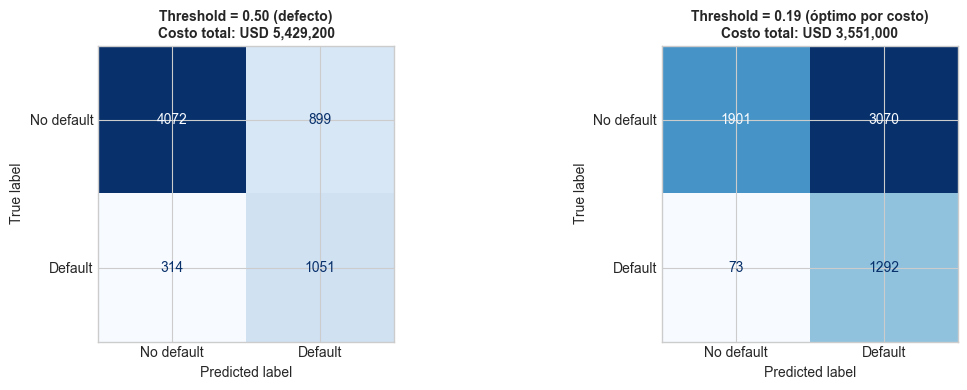

In [51]:
# ── Comparar matrices de confusión: th=0.5 vs th=óptimo ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, th, title in zip(
    axes,
    [0.5, th_optimo],
    [f'Threshold = 0.50 (defecto)', f'Threshold = {th_optimo:.2f} (óptimo por costo)']
):
    y_pred_th = (proba_logit >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    
    tn, fp, fn, tp = cm.ravel()
    costo = fn * COSTO_FN + fp * COSTO_FP
    ax.set_title(f'{title}\nCosto total: USD {costo:,.0f}', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


In [52]:
# ── Métricas finales con threshold óptimo ─────────────────────────────────
y_pred_opt = (proba_logit >= th_optimo).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()

sensibilidad  = tp / (tp + fn)
especificidad = tn / (tn + fp)
ppv           = tp / (tp + fp)  # Precisión / Valor Predictivo Positivo

print(f"{'='*50}")
print(f"MÉTRICAS CON THRESHOLD ÓPTIMO ({th_optimo:.2f})")
print(f"{'='*50}")
print(f"Sensibilidad (Recall):  {sensibilidad:.1%}  — de cada 100 defaults, detecto {sensibilidad*100:.0f}")
print(f"Especificidad:          {especificidad:.1%}  — de cada 100 buenos, apruebo {especificidad*100:.0f}")
print(f"Precisión (PPV):        {ppv:.1%}  — de cada 100 rechazados, {ppv*100:.0f} eran realmente malos")
print(f"AUC:                    {auc_logit:.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=['No default', 'Default']))


MÉTRICAS CON THRESHOLD ÓPTIMO (0.19)
Sensibilidad (Recall):  94.7%  — de cada 100 defaults, detecto 95
Especificidad:          38.2%  — de cada 100 buenos, apruebo 38
Precisión (PPV):        29.6%  — de cada 100 rechazados, 30 eran realmente malos
AUC:                    0.8596

              precision    recall  f1-score   support

  No default       0.96      0.38      0.55      4971
     Default       0.30      0.95      0.45      1365

    accuracy                           0.50      6336
   macro avg       0.63      0.66      0.50      6336
weighted avg       0.82      0.50      0.53      6336



---
## ⭐ Sección 5 · Regresión Logística vs LDA

### ¿Cuándo usar cada uno?

> 🍎 **Analogía del sastre:**
> - **Logística** = Sastre a medida. No asume nada de tu cuerpo, te toma medidas y hace el traje perfecto. Funciona con casi cualquier cliente.
> - **LDA** = Tienda de tallas estándar. Asume que los clientes siguen cierto patrón (distribución normal). Si eres "estándar", el traje queda perfecto y es más barato. Si eres muy peculiar, el traje queda torcido.

| | Logística | LDA |
|-|-----------|-----|
| Supuesto sobre X | Ninguno | Distribución Normal por clase |
| Outliers | Resistente ✅ | Sensible ❌ |
| Múltiples clases | Con ajuste | Natural ✅ |
| ¿Cuándo gana? | Datos raros/asimétricos | Datos bien portados y normales |


In [53]:
# ── Entrenar LDA ─────────────────────────────────────────────────────────────

lda = LDA()
lda.fit(X_train_clean, y_train)  # usa X_train_clean (ya sin NaN, igual que logit)

proba_lda = lda.predict_proba(X_test_clean)[:, 1]
auc_lda   = roc_auc_score(y_test, proba_lda)

print(f"AUC Logística: {auc_logit:.4f}")
print(f"AUC LDA:       {auc_lda:.4f}")

diff    = abs(auc_logit - auc_lda)
ganador = 'Logística' if auc_logit > auc_lda else 'LDA'
print(f"Diferencia:    {diff:.4f} → Gana: {ganador}")


AUC Logística: 0.8596
AUC LDA:       0.8551
Diferencia:    0.0045 → Gana: Logística


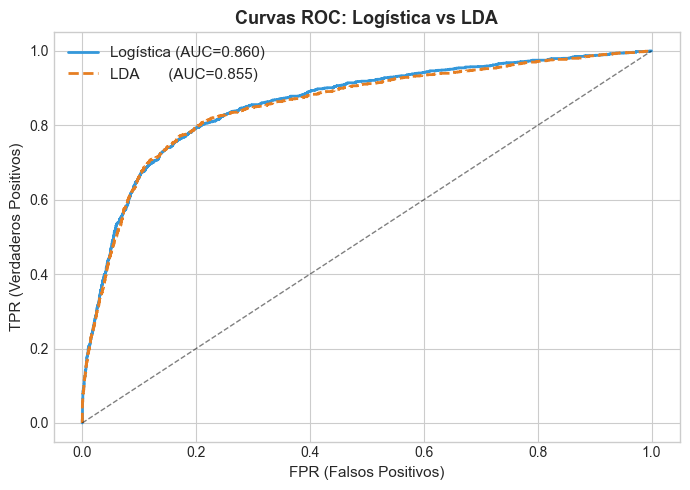


💡 Con este dataset, la diferencia es de solo 0.0045 en AUC.
   Cuando los datos tienen outliers (como vimos en el EDA), Logística es más robusta.
   Si los datos fueran perfectamente normales y balanceados, LDA suele ser igual o mejor.


In [54]:
# ── Curvas ROC comparadas ─────────────────────────────────────────────────
fpr_lda, tpr_lda, _ = roc_curve(y_test, proba_lda)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'Logística (AUC={auc_logit:.3f})')
plt.plot(fpr_lda, tpr_lda, color='#e67e22', lw=2, linestyle='--',
         label=f'LDA       (AUC={auc_lda:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlabel('FPR (Falsos Positivos)', fontsize=11)
plt.ylabel('TPR (Verdaderos Positivos)', fontsize=11)
plt.title('Curvas ROC: Logística vs LDA', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n💡 Con este dataset, la diferencia es de solo {diff:.4f} en AUC.")
print("   Cuando los datos tienen outliers (como vimos en el EDA), Logística es más robusta.")
print("   Si los datos fueran perfectamente normales y balanceados, LDA suele ser igual o mejor.")


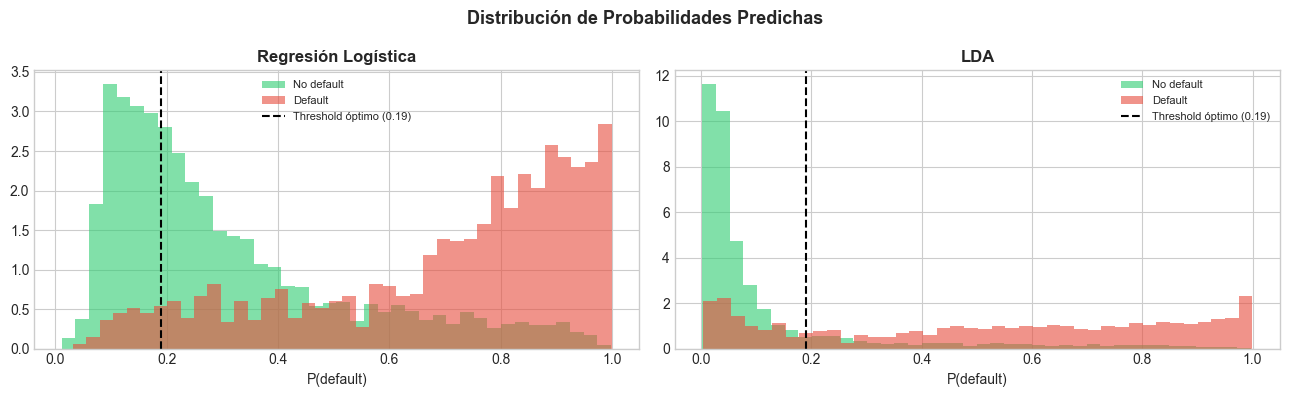

💡 Un buen modelo separa bien las dos distribuciones (verde vs rojo).
   Cuanto menos se superpongan, mejor es el modelo.


In [55]:
# ── Distribución de probabilidades predichas ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, proba, titulo in zip(axes,
                               [proba_logit, proba_lda],
                               ['Regresión Logística', 'LDA']):
    ax.hist(proba[y_test == 0], bins=40, alpha=0.6, color='#2ecc71',
            label='No default', density=True)
    ax.hist(proba[y_test == 1], bins=40, alpha=0.6, color='#e74c3c',
            label='Default', density=True)
    ax.axvline(th_optimo, color='black', lw=1.5, linestyle='--',
               label=f'Threshold óptimo ({th_optimo:.2f})')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('P(default)')
    ax.legend(fontsize=8)

plt.suptitle('Distribución de Probabilidades Predichas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("💡 Un buen modelo separa bien las dos distribuciones (verde vs rojo).")
print("   Cuanto menos se superpongan, mejor es el modelo.")


---
## ⭐ Sección 6 · Reporte Ejecutivo de Scoring

> 🍎 **Analogía del informe médico:**  
> El médico sabe exactamente qué reactivos usó, qué análisis corrió, qué estadísticas calculó.  
> Pero lo que le da al paciente es un papel que dice: *"Su presión está alta. Tome esta pastilla."*  
>
> El reporte ejecutivo de scoring es igual: toda la cocina técnica queda en el notebook.  
> Al **gerente de riesgos** le das **una página** con los números que importan y las decisiones claras.

### ¿Qué incluye el reporte?
1. **Metadatos del modelo** (AUC, threshold, tamaño del dataset)
2. **Tabla de coeficientes con OR** (qué variables mueven el riesgo y cuánto)
3. **Decisiones para nuevos solicitantes** (APROBAR / RECHAZAR / REVISAR)


In [56]:
# ── Función de reporte ejecutivo ─────────────────────────────────────────────
def scoring_report(model, X_test_input, y_test, threshold, feature_names, modelo_nombre='Logística'):
    """
    Genera el reporte ejecutivo de scoring.
    
    Parámetros:
    -----------
    model         : modelo entrenado con predict_proba
    X_test_input  : features de test (limpias, sin NaN)
    y_test        : etiquetas reales de test
    threshold     : threshold óptimo elegido
    feature_names : lista con nombres de features
    modelo_nombre : nombre para el encabezado
    """
    proba  = model.predict_proba(X_test_input)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    auc    = roc_auc_score(y_test, proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    print("=" * 60)
    print(f"  REPORTE EJECUTIVO DE SCORING — {modelo_nombre}")
    print("=" * 60)
    print(f"  Modelo:           {modelo_nombre}")
    print(f"  AUC test:         {auc:.4f}")
    print(f"  Threshold óptimo: {threshold:.2f}")
    print(f"  N test:           {len(y_test):,}")
    print("-" * 60)
    print(f"  MÉTRICAS EN TEST (threshold = {threshold:.2f})")
    print(f"  Sensibilidad:  {tp/(tp+fn):.1%}  (capturamos el {tp/(tp+fn)*100:.0f}% de los defaults)")
    print(f"  Especificidad: {tn/(tn+fp):.1%}  (aprobamos el {tn/(tn+fp)*100:.0f}% de los buenos)")
    print(f"  Precisión:     {tp/(tp+fp):.1%}  (de los rechazados, {tp/(tp+fp)*100:.0f}% eran reales defaults)")
    print("-" * 60)

    if hasattr(model, 'coef_'):
        OR = np.exp(model.coef_[0])
        coef_tabla = pd.DataFrame({
            'Feature':        feature_names,
            'β̂':             model.coef_[0].round(3),
            'OR':             OR.round(3),
            'Interpretación': ['↑ +riesgo' if o > 1 else '↓ -riesgo' for o in OR]
        }).sort_values('OR', ascending=False)
        print("  TOP PREDICTORES (Odds Ratio):")
        print(coef_tabla.head(5).to_string(index=False))

    print("=" * 60)
    return proba

# ── Llamada al reporte — nota: X_test_clean en lugar de X_test_sc ─────────────
proba_final = scoring_report(
    logit, X_test_clean, y_test,        # <── X_test_clean, no X_test_sc
    threshold=th_optimo,
    feature_names=FEATURES,
    modelo_nombre='Regresión Logística'
)

  REPORTE EJECUTIVO DE SCORING — Regresión Logística
  Modelo:           Regresión Logística
  AUC test:         0.8596
  Threshold óptimo: 0.19
  N test:           6,336
------------------------------------------------------------
  MÉTRICAS EN TEST (threshold = 0.19)
  Sensibilidad:  94.7%  (capturamos el 95% de los defaults)
  Especificidad: 38.2%  (aprobamos el 38% de los buenos)
  Precisión:     29.6%  (de los rechazados, 30% eran reales defaults)
------------------------------------------------------------
  TOP PREDICTORES (Odds Ratio):
            Feature    β̂    OR Interpretación
loan_percent_income 1.311 3.711      ↑ +riesgo
       loan_grade_D 0.814 2.256      ↑ +riesgo
       loan_grade_E 0.488 1.630      ↑ +riesgo
       loan_grade_G 0.351 1.420      ↑ +riesgo
       loan_grade_F 0.274 1.315      ↑ +riesgo


In [57]:
# ── Decisiones para nuevos solicitantes ───────────────────────────────────
# Simulamos 5 perfiles de nuevos solicitantes

print("=" * 60)
print("  DECISIONES PARA NUEVOS SOLICITANTES")
print("=" * 60)
print(f"  Threshold: {th_optimo:.2f} | P > {th_optimo:.2f} → RECHAZAR")
print("-" * 60)

nuevos_clientes = {
    'Cliente A (joven, bajo ingreso, grado D)': {
        'person_age': 24, 'person_income': 25000, 'person_emp_length': 1,
        'loan_amnt': 8000, 'loan_int_rate': 18.0, 'loan_percent_income': 0.32,
        'cb_person_cred_hist_length': 2, 'cb_default_bin': 1,
        'loan_grade_B': 0, 'loan_grade_C': 0, 'loan_grade_D': 1,
        'loan_grade_E': 0, 'loan_grade_F': 0, 'loan_grade_G': 0
    },
    'Cliente B (mayor, alto ingreso, grado A)': {
        'person_age': 45, 'person_income': 95000, 'person_emp_length': 15,
        'loan_amnt': 5000, 'loan_int_rate': 7.5, 'loan_percent_income': 0.05,
        'cb_person_cred_hist_length': 18, 'cb_default_bin': 0,
        'loan_grade_B': 0, 'loan_grade_C': 0, 'loan_grade_D': 0,
        'loan_grade_E': 0, 'loan_grade_F': 0, 'loan_grade_G': 0
    },
    'Cliente C (perfil medio, grado C)': {
        'person_age': 34, 'person_income': 52000, 'person_emp_length': 6,
        'loan_amnt': 12000, 'loan_int_rate': 12.5, 'loan_percent_income': 0.23,
        'cb_person_cred_hist_length': 7, 'cb_default_bin': 0,
        'loan_grade_B': 0, 'loan_grade_C': 1, 'loan_grade_D': 0,
        'loan_grade_E': 0, 'loan_grade_F': 0, 'loan_grade_G': 0
    },
    'Cliente D (alto riesgo, grado F)': {
        'person_age': 28, 'person_income': 30000, 'person_emp_length': 2,
        'loan_amnt': 20000, 'loan_int_rate': 22.0, 'loan_percent_income': 0.67,
        'cb_person_cred_hist_length': 3, 'cb_default_bin': 1,
        'loan_grade_B': 0, 'loan_grade_C': 0, 'loan_grade_D': 0,
        'loan_grade_E': 0, 'loan_grade_F': 1, 'loan_grade_G': 0
    },
    'Cliente E (senior estable, grado B)': {
        'person_age': 55, 'person_income': 78000, 'person_emp_length': 22,
        'loan_amnt': 3000, 'loan_int_rate': 9.0, 'loan_percent_income': 0.04,
        'cb_person_cred_hist_length': 25, 'cb_default_bin': 0,
        'loan_grade_B': 1, 'loan_grade_C': 0, 'loan_grade_D': 0,
        'loan_grade_E': 0, 'loan_grade_F': 0, 'loan_grade_G': 0
    }
}

for nombre, datos in nuevos_clientes.items():
    # Armar el vector de features en el mismo orden
    row = pd.DataFrame([datos])[FEATURES]
    row_sc = scaler.transform(row)
    prob = logit.predict_proba(row_sc)[0, 1]
    
    if prob < th_optimo * 0.6:
        decision = "✅ APROBAR"
    elif prob < th_optimo:
        decision = "⚠️  REVISAR (cerca del límite)"
    else:
        decision = "❌ RECHAZAR"
    
    print(f"  {nombre}")
    print(f"     P(default) = {prob:.3f}  →  {decision}")
    print()


  DECISIONES PARA NUEVOS SOLICITANTES
  Threshold: 0.19 | P > 0.19 → RECHAZAR
------------------------------------------------------------
  Cliente A (joven, bajo ingreso, grado D)
     P(default) = 0.981  →  ❌ RECHAZAR

  Cliente B (mayor, alto ingreso, grado A)
     P(default) = 0.073  →  ✅ APROBAR

  Cliente C (perfil medio, grado C)
     P(default) = 0.517  →  ❌ RECHAZAR

  Cliente D (alto riesgo, grado F)
     P(default) = 1.000  →  ❌ RECHAZAR

  Cliente E (senior estable, grado B)
     P(default) = 0.106  →  ✅ APROBAR



/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  war

/var/folders/mr/sqx7yj1d7qs1fr_mry8vz2x80000gn/T/ipykernel_72023/1254659682.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/josefrodriguez/repos/modelos_estadisticos/modelos_estadisticos/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


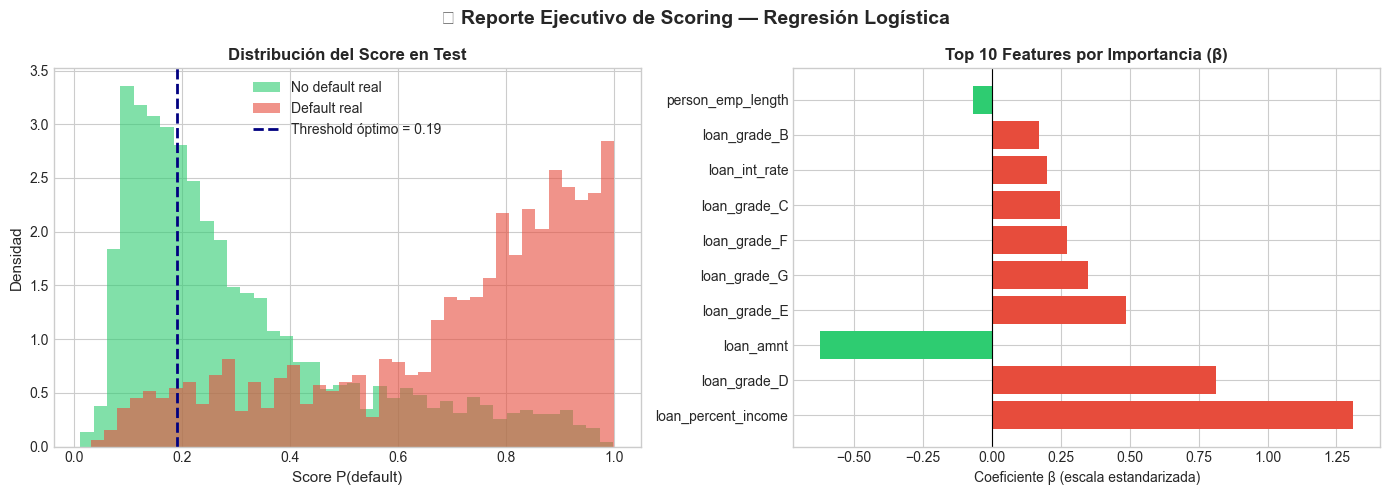

In [58]:
# ── Visualización del reporte ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Score distribution en test
axes[0].hist(proba_final[y_test == 0], bins=40, alpha=0.6, color='#2ecc71',
             label='No default real', density=True)
axes[0].hist(proba_final[y_test == 1], bins=40, alpha=0.6, color='#e74c3c',
             label='Default real', density=True)
axes[0].axvline(th_optimo, color='navy', lw=2, linestyle='--',
                label=f'Threshold óptimo = {th_optimo:.2f}')
axes[0].set_xlabel('Score P(default)', fontsize=11)
axes[0].set_ylabel('Densidad', fontsize=11)
axes[0].set_title('Distribución del Score en Test', fontsize=12, fontweight='bold')
axes[0].legend()

# Panel 2: Top 10 features por |coef|
top_features = pd.DataFrame({'Feature': FEATURES, 'coef': logit.coef_[0]})
top_features['abs_coef'] = top_features['coef'].abs()
top_features = top_features.nlargest(10, 'abs_coef')
colors_coef = ['#e74c3c' if c > 0 else '#2ecc71' for c in top_features['coef']]

axes[1].barh(top_features['Feature'], top_features['coef'], color=colors_coef)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Top 10 Features por Importancia (β)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coeficiente β (escala estandarizada)', fontsize=10)

plt.suptitle('📊 Reporte Ejecutivo de Scoring — Regresión Logística', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## ✅ Resumen de la Clase 07

| Concepto | Lo que aprendimos | Analogía |
|----------|-------------------|----------|
| **Threshold** | No siempre es 0.5 — depende de los costos del negocio | El guardia del nightclub decide su propio límite de entrada |
| **FN vs FP** | Cada error tiene un costo distinto | Manzana podrida vendida vs manzana buena tirada |
| **Threshold óptimo** | `argmin FN·cost_FN + FP·cost_FP` | El punto más bajo de la curva de costos |
| **AUC vs Threshold** | AUC = calidad del modelo / Threshold = política del banco | El examen vs la nota de corte para aprobar |
| **Logística vs LDA** | Logística más robusta con outliers; LDA más eficiente con datos normales | Sastre a medida vs talla estándar |
| **Reporte ejecutivo** | Una página: AUC + threshold + OR + decisiones | Informe médico: diagnóstico claro, sin jerga técnica |

---
### 🎓 Próxima clase
**Módulo 3 — Análisis Discriminante Lineal (LDA)**  
Fisher · QDA · Clasificación multiclase
